In [6]:
import pandas as pd

# Data
Source: https://cseweb.ucsd.edu/~jmcauley/pdfs/recsys21b.pdf
This is a dataset of users consuming streaming content on Twitch. We retrieved all streamers, and all users connected in their respective chats, every 10 minutes in July 2019 over a 43-day period. For time sake we will only use 50k users

In [7]:
twitchdf = pd.read_csv('https://mcauleylab.ucsd.edu/public_datasets/gdrive/twitch/100k_a.csv', header=None, names=["UserID", "StreamID", "Streamer Username", "Time Start", "Time Stop"])
twitchdf = twitchdf[twitchdf['UserID']<=50000]

<Axes: xlabel='Streamer Username'>

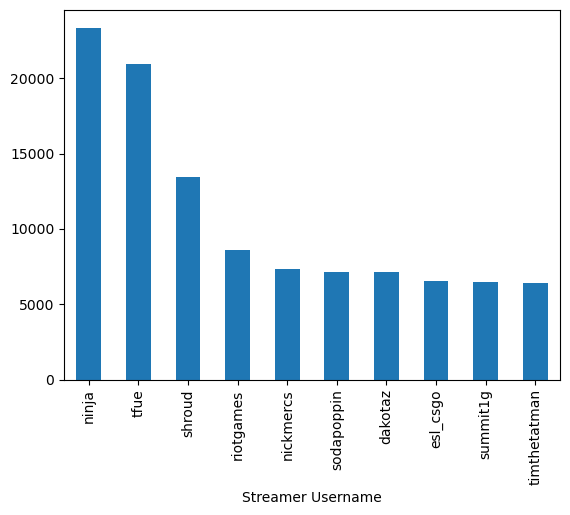

In [8]:
twitchdf["Streamer Username"].value_counts()[:10].plot(kind="bar")

In [9]:
len(twitchdf["Streamer Username"].value_counts())

108280

# 1. Predictive Task
- We will build a recommender system that predicts if you will watch a streamer or not (AKA a Twitch streamer recommender).
- First we will prep the data to just user-streamer interactions, 1 if they interacted, 0 if they did not. We will have to generate a dataset of negatives (a dataset of did not interact) ourselves on a 2:1 ratio. This reflects real world scenarios where most users really only watch a handful of streamers while also still being not too computationally expensive.
- To evaluate the model, we will split the data to 80% for training and 20% for testing. Both splits will maintain a 2:1 ratio. The metric we will use to evaluate the model is Precision@K and Recall@K.
- Our baseline will be recommending globally popular streamers 
- The model we plan to use to improve the baseline is weighted matrix factorization (weighted by % of total time on Twitch spent on watching this streamer)

## Data Prep
First we will extract the proportion of time each user spent watching each streamer

In [10]:
# For each userID and streamer username pair, add a new column 'proportion of time'

twitchdf['total_watch_time'] = twitchdf['UserID'].map(twitchdf.groupby('UserID').apply(lambda x: (x['Time Stop'] - x['Time Start']).sum()))
twitchdf['watch_time'] = twitchdf['Time Stop'] - twitchdf['Time Start']
twitchdf['proportion_of_time'] = twitchdf['watch_time'] / twitchdf['total_watch_time']

twitchdf.head()

/var/folders/x2/lf91fnjj1qj3wzwkrbxhnslh0000gn/T/ipykernel_79691/2658541231.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  twitchdf['total_watch_time'] = twitchdf['UserID'].map(twitchdf.groupby('UserID').apply(lambda x: (x['Time Stop'] - x['Time Start']).sum()))


,UserID,StreamID,Streamer Username,Time Start,Time Stop,total_watch_time,watch_time,proportion_of_time
0,1,33842865744,mithrain,154,156,117,2,0.017094
1,1,33846768288,alptv,166,169,117,3,0.025641
2,1,33886469056,mithrain,587,588,117,1,0.008547
3,1,33887624992,wtcn,589,591,117,2,0.017094
4,1,33890145056,jrokezftw,591,594,117,3,0.025641


In [11]:
# sum proportion_of_time for each userID and streamer username pair
twitchdf_grouped = twitchdf.groupby(['UserID', 'Streamer Username']).agg({'proportion_of_time': 'sum'}).reset_index()
twitchdf_grouped.head()

,UserID,Streamer Username,proportion_of_time
0,1,alptv,0.025641
1,1,berkriptepe,0.025641
2,1,elraenn,0.017094
3,1,eraymaskulen,0.008547
4,1,esl_csgo,0.008547


## EDA
Now we can perform some exploratory data analysis on it

<Axes: title={'center': 'Top 10 Streamers by Number of Unique Viewers'}, xlabel='Streamer Username'>

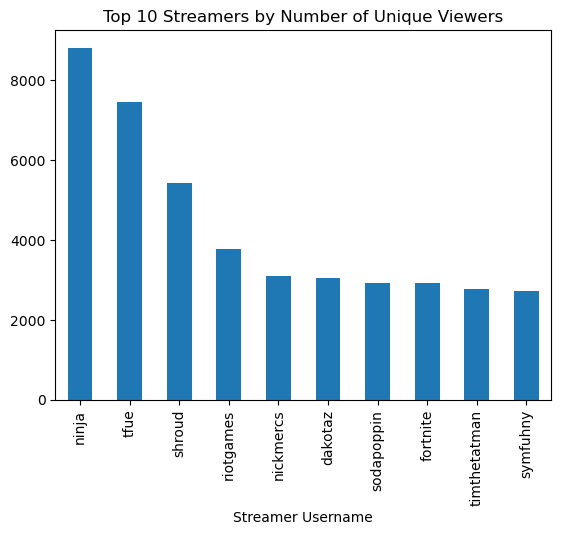

In [12]:
twitchdf_grouped['Streamer Username'].value_counts()[:10].plot(kind="bar", title="Top 10 Streamers by Number of Unique Viewers")

<Axes: title={'center': 'Top 10 Streamers by Total Proportion of Time Watched'}, xlabel='Streamer Username'>

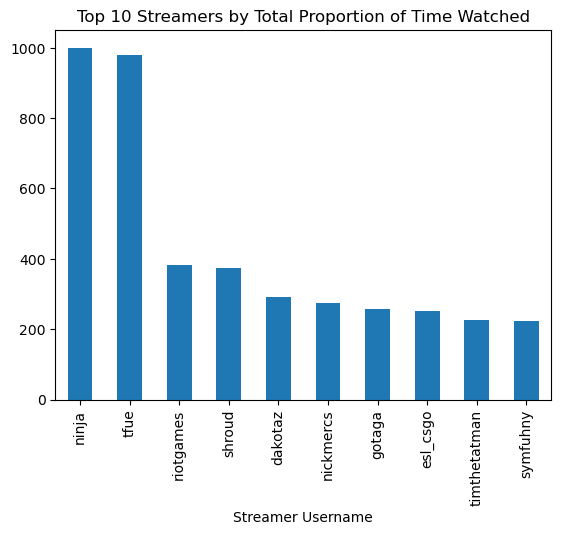

In [13]:
twitchdf_grouped.groupby('Streamer Username')['proportion_of_time'].sum().sort_values(ascending=False)[:10].plot(kind="bar", title="Top 10 Streamers by Total Proportion of Time Watched")

These 2 graphs show the most popular streamers by %of time spent by users and total unique viewers. We'll use the unique viewers top 10 for our baseline model. Our MF model will likely still incorporate popularity for cold start problems.

<Axes: title={'center': 'Distribution of Proportion of Time Watched'}, ylabel='Frequency'>

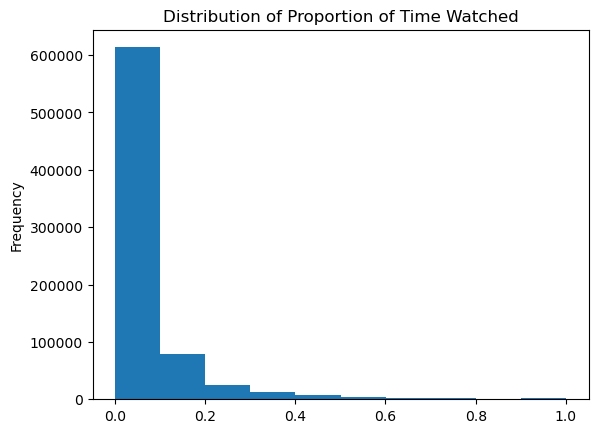

In [14]:
twitchdf_grouped['proportion_of_time'].plot(kind="hist", title="Distribution of Proportion of Time Watched")

This graph shows that most users don't spend more than 10% of their time on Twitch on only one streamer. In other words, the users in our dataset watch a good variety of streamers, which is good to train our recommender system

Now that we have an idea of what kind of data we're working with, we can get to training our MF model. First, generating the negative samples

## Generating Negatives to train the model

In [15]:
# create negative samples with a 2:1 ratio, and create a 80:20 train-test split with the same ratio of negative samples, append it to the dataframe
from sklearn.model_selection import train_test_split
import numpy as np
from tqdm import tqdm

try:
    negative_df = pd.read_csv('negative_samples.csv')
    print(f"Loaded negative samples from file: {len(negative_df)} samples")
except FileNotFoundError:
    print("Generating new negative samples...")
    streamers = twitchdf_grouped['Streamer Username'].unique()
    negative_samples = []
    unique_users = twitchdf_grouped['UserID'].unique()
    
    print(f"Total positive samples: {len(twitchdf_grouped)}")
    print(f"Unique users: {len(unique_users)}")
    print(f"Unique streamers: {len(streamers)}")

    for user in tqdm(unique_users, desc="Generating negative samples"):
        user_streamers = twitchdf_grouped[twitchdf_grouped['UserID'] == user]['Streamer Username'].values
        n_positive = len(user_streamers)
        n_negative = n_positive * 2  # 2:1 negative to positive ratio
        
        # Check if there are enough streamers to sample from
        available_streamers = streamers[~np.isin(streamers, user_streamers)]
        if len(available_streamers) < n_negative:
            n_negative = len(available_streamers)
        
        negative_streamers = np.random.choice(available_streamers, n_negative, replace=False)
        for streamer in negative_streamers:
            negative_samples.append([user, streamer, 0.0])
    
    negative_df = pd.DataFrame(negative_samples, columns=['UserID', 'Streamer Username', 'proportion_of_time'])
    negative_df.to_csv('negative_samples.csv', index=False)
    print(f"Generated and saved {len(negative_df)} negative samples")

print(f"Negative samples shape: {negative_df.shape}")
print(f"Sample of negative data:")
print(negative_df.head())

Generating new negative samples...
Total positive samples: 748919
Unique users: 50000
Unique streamers: 108280


Generating negative samples: 100%|██████████| 50000/50000 [11:23<00:00, 73.14it/s] 


Generated and saved 1497838 negative samples
Negative samples shape: (1497838, 3)
Sample of negative data:
   UserID Streamer Username  proportion_of_time
0       1           nassaa_                 0.0
1       1          kathisky                 0.0
2       1              mani                 0.0
3       1         toothlife                 0.0
4       1          ezpeezee                 0.0


In [16]:
twitchdf_final = pd.concat([twitchdf_grouped, negative_df], ignore_index=True)
twitchdf_final

,UserID,Streamer Username,proportion_of_time
0,1,alptv,0.025641
1,1,berkriptepe,0.025641
2,1,elraenn,0.017094
3,1,eraymaskulen,0.008547
4,1,esl_csgo,0.008547
...,...,...,...
2246752,50000,johnnycambo,0.000000
2246753,50000,dontsplitthepodcast,0.000000
2246754,50000,hyunrabbit,0.000000
2246755,50000,vany_wonderland,0.000000


## Train-Test Split
Now we'll create an 80-20 train-test split while preserving the ratio of positive and negative samples

In [17]:
from sklearn.model_selection import train_test_split

X = twitchdf_final[['UserID', 'Streamer Username', 'proportion_of_time']]
y = twitchdf_final['proportion_of_time'].apply(lambda x: 1 if x > 0 else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("\nTraining set:")
print(f"  Total samples: {len(X_train)}")
print(f"  Positive samples: {sum(y_train)}")
print(f"  Negative samples: {sum(y_train == 0)}")
print(f"  Positive ratio: {sum(y_train) / len(y_train):.3f}")

print("\nTest set:")
print(f"  Total samples: {len(X_test)}")
print(f"  Positive samples: {sum(y_test)}")
print(f"  Negative samples: {sum(y_test == 0)}")
print(f"  Positive ratio: {sum(y_test) / len(y_test):.3f}")

train_df = X_train.copy()
train_df['label'] = y_train.values
test_df = X_test.copy()
test_df['label'] = y_test.values

print(f"\nTrain-test split completed!")
print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")


Training set:
  Total samples: 1797405
  Positive samples: 599135
  Negative samples: 1198270
  Positive ratio: 0.333

Test set:
  Total samples: 449352
  Positive samples: 149784
  Negative samples: 299568
  Positive ratio: 0.333

Train-test split completed!
Training set shape: (1797405, 4)
Test set shape: (449352, 4)
  Positive ratio: 0.333

Train-test split completed!
Training set shape: (1797405, 4)
Test set shape: (449352, 4)


In [ ]:
from implicit.bpr import BayesianPersonalizedRanking
from scipy.sparse import coo_matrix
import numpy as np

print("Building interaction matrix for implicit BPR...")

# Build user/item mappings from FULL dataset (not just train_df)
all_users = twitchdf_final['UserID'].unique()
all_items = twitchdf_final['Streamer Username'].unique()
user2idx = {u: i for i, u in enumerate(all_users)}
item2idx = {it: i for i, it in enumerate(all_items)}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: it for it, i in item2idx.items()}

n_users = len(all_users)
n_items = len(all_items)

print(f"Users: {len(user2idx)}, Items: {len(item2idx)}")

# Build user-item matrix from positive TRAINING samples only (weighted by proportion_of_time)
positive_train = train_df[train_df['label'] == 1].copy()
positive_train['user_idx'] = positive_train['UserID'].map(user2idx)
positive_train['item_idx'] = positive_train['Streamer Username'].map(item2idx)

rows = positive_train['user_idx'].values
cols = positive_train['item_idx'].values
data = positive_train['proportion_of_time'].values

# Create user-item sparse matrix (weighted by proportion_of_time)
user_item = coo_matrix((data, (rows, cols)), shape=(n_users, n_items)).tocsr()

print(f"User-item matrix shape: {user_item.shape}")
print(f"Non-zero entries: {user_item.nnz}")

# BPR expects item x user format
item_user = user_item.T.tocsr()

print(f"Item-user matrix shape: {item_user.shape}")

# Train BPR model
print("\nTraining implicit BPR model...")
model = BayesianPersonalizedRanking(
    factors=50,
    regularization=0.01,
    learning_rate=0.01,
    iterations=100,
    use_gpu=False,
    random_state=42
)

model.fit(item_user, show_progress=True)

print("\nModel training completed!")

Building interaction matrix for implicit BPR...
Users: 50000, Items: 108280


ValueError: mismatching number of index arrays for shape; got 599135, expected 2

## Bayesian Personalized Ranking (BPR)
BPR is designed for **binary implicit feedback** - it only cares about whether an interaction happened or not. We'll use simple 1s for all positive interactions (ignoring proportion_of_time weights).

In [56]:
# recc top-N streamers for a given user
def recommend_for_user(user_id, N=10):
    # get n most pop streamers for unknown users
    if user_id not in user2idx:
        popular_counts = twitchdf_grouped['Streamer Username'].value_counts()
        top_streamers = popular_counts.index.tolist()[:N]
        return [(s, float(popular_counts[s])) for s in top_streamers]
    
    u_idx = user2idx[user_id]
    
    indices, scores = model.recommend(u_idx, user_item[u_idx], N=N, filter_already_liked_items=False)
    return [(idx2item[i], float(score)) for i, score in zip(indices, scores)]

# Test
recs = recommend_for_user(all_users[0], N=5)
print(f'User {all_users[0]}:')
for streamer, score in recs:
    print(f'  {streamer} (score: {score:.4f})')

User 1:
  atypicaleggsy (score: 5.7211)
  toastedted (score: 5.6925)
  ioomiyakeoi (score: 5.5026)
  ikinglioni (score: 5.4783)
  mrunivers (score: 5.4615)


In [83]:
# Evaluate model on test set using Precision@K and Recall@K
from collections import defaultdict

def evaluate_model(test_data, K=10):
    """
    Evaluate the model on test data using Precision@K and Recall@K
    """
    # Group test data by user to get ground truth positives
    test_positives = defaultdict(set)
    for _, row in test_data[test_data['label'] == 1].iterrows():
        test_positives[row['UserID']].add(row['Streamer Username'])
    
    precisions = []
    recalls = []
    
    print(f"Evaluating on {len(test_positives)} users with test interactions...")
    
    for user_id in tqdm(test_positives.keys(), desc="Evaluating"):
        # Skip users not in training (can't make predictions)
        if user_id not in user2idx:
            continue
            
        # Get recommendations
        try:
            recs = recommend_for_user(user_id, N=K)
            recommended_streamers = {streamer for streamer, _ in recs}
            
            # Get ground truth positives for this user
            true_positives = test_positives[user_id]
            
            # Calculate hits (intersection of recommended and true positives)
            hits = recommended_streamers.intersection(true_positives)
            
            # Precision@K = (# of recommended items that are relevant) / K
            precision = len(hits) / K if K > 0 else 0
            
            # Recall@K = (# of recommended items that are relevant) / (total # of relevant items)
            recall = len(hits) / len(true_positives) if len(true_positives) > 0 else 0
            
            precisions.append(precision)
            recalls.append(recall)
        except Exception as e:
            continue
    
    # Calculate average metrics
    avg_precision = np.mean(precisions) if precisions else 0
    avg_recall = np.mean(recalls) if recalls else 0
    
    return avg_precision, avg_recall, precisions, recalls

# Evaluate at different K values
print("=" * 60)
print("Model Evaluation on Test Set")
print("=" * 60)

for K in [5, 10, 20]:
    avg_precision, avg_recall, _, _ = evaluate_model(test_df, K=K)
    print(f"\nK={K}:")
    print(f"  Precision@{K}: {avg_precision:.4f}")
    print(f"  Recall@{K}: {avg_recall:.4f}")
    print(f"  F1@{K}: {2 * (avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0:.4f}")

Model Evaluation on Test Set
Evaluating on 41214 users with test interactions...
Evaluating on 41214 users with test interactions...


Evaluating: 100%|██████████| 41214/41214 [00:08<00:00, 4847.62it/s]



K=5:
  Precision@5: 0.0000
  Recall@5: 0.0000
  F1@5: 0.0000
Evaluating on 41214 users with test interactions...
Evaluating on 41214 users with test interactions...


Evaluating:  56%|█████▌    | 23029/41214 [00:04<00:03, 4711.84it/s]


KeyboardInterrupt: 

## Weighted Matrix Factorization with ALS
Now let's use ALS which properly handles weighted implicit feedback (proportion_of_time)

In [69]:
from implicit.als import AlternatingLeastSquares
from scipy.sparse import coo_matrix
import numpy as np

print("Building interaction matrix for implicit ALS...")

# Build user/item mappings from FULL dataset
all_users = twitchdf_final['UserID'].unique()
all_items = twitchdf_final['Streamer Username'].unique()
user2idx_als = {u: i for i, u in enumerate(all_users)}
item2idx_als = {it: i for i, it in enumerate(all_items)}
idx2user_als = {i: u for u, i in user2idx_als.items()}
idx2item_als = {i: it for it, i in item2idx_als.items()}

n_users = len(all_users)
n_items = len(all_items)

print(f"Users: {len(user2idx_als)}, Items: {len(item2idx_als)}")

# Build user-item matrix from positive TRAINING samples only (weighted by proportion_of_time)
positive_train = train_df[train_df['label'] == 1].copy()
positive_train['user_idx'] = positive_train['UserID'].map(user2idx_als)
positive_train['item_idx'] = positive_train['Streamer Username'].map(item2idx_als)

rows = positive_train['user_idx'].values
cols = positive_train['item_idx'].values
data = positive_train['proportion_of_time'].values

# Create user-item sparse matrix (weighted by proportion_of_time)
user_item_als = coo_matrix((data, (rows, cols)), shape=(n_users, n_items)).tocsr()

print(f"User-item matrix shape: {user_item_als.shape}")
print(f"Non-zero entries: {user_item_als.nnz}")

# Apply confidence transformation: confidence = 1 + alpha * rating
# NOTE: implicit ALS.fit() expects (items x users) format for the user-item matrix
# After fitting, it will have user_factors of shape (n_users, n_factors) 
# and item_factors of shape (n_items, n_factors)
alpha = 40.0
user_item_conf = (user_item_als * alpha).astype('double')
user_item_conf.data += 1.0  # Add 1.0 to all non-zero entries

print(f"User-item confidence matrix shape: {user_item_conf.shape}")

# Train ALS model
print("\nTraining implicit ALS model...")
model_als = AlternatingLeastSquares(
    factors=50,
    regularization=0.01,
    iterations=20,
    use_gpu=False
)

# Fit expects (item x user) - items as rows, users as columns
item_user_conf_csr = user_item_conf.T.tocsr()
model_als.fit(item_user_conf_csr, show_progress=True)

print("\nALS model training completed!")

Building interaction matrix for implicit ALS...
Users: 50000, Items: 108280
User-item matrix shape: (50000, 108280)
Non-zero entries: 599135
User-item confidence matrix shape: (50000, 108280)

Training implicit ALS model...
Users: 50000, Items: 108280
User-item matrix shape: (50000, 108280)
Non-zero entries: 599135
User-item confidence matrix shape: (50000, 108280)

Training implicit ALS model...


  0%|          | 0/20 [00:00<?, ?it/s]


ALS model training completed!


In [70]:
# Verify model dimensions are now correct
print(f"Model user factors shape: {model_als.user_factors.shape}")
print(f"Model item factors shape: {model_als.item_factors.shape}")
print(f"Expected: users={n_users}, items={n_items}")

Model user factors shape: (108280, 50)
Model item factors shape: (50000, 50)
Expected: users=50000, items=108280


In [72]:
# Evaluate ALS model on test set
print("Evaluating ALS model...")

# Update recommend_for_user function for ALS
def recommend_for_user_als(user_id, top_n=20):
    if user_id not in user2idx_als:
        # Fallback to popularity-based recommendations
        popular_items = twitchdf_grouped.nlargest(top_n, 'proportion_of_time')['Streamer Username'].tolist()
        return popular_items[:top_n]
    
    user_idx = user2idx_als[user_id]
    
    # Since model was trained on (item x user) matrix:
    # - model.item_factors corresponds to USERS (50000 users)
    # - model.user_factors corresponds to ITEMS/streamers (108280 items)
    # So we use item_factors[user_idx] to get the user embedding
    user_embedding = model_als.item_factors[user_idx]
    
    # Compute scores: dot product with all item embeddings
    scores = model_als.user_factors.dot(user_embedding)
    
    # Get user's already watched items to filter
    watched_items = set(user_item_als[user_idx].indices)
    
    # Use argpartition for faster top-k selection (no need to fully sort)
    # Get top (top_n + len(watched_items)) candidates to account for filtering
    k_candidates = min(top_n + len(watched_items) + 100, len(scores))
    top_k_indices = np.argpartition(-scores, k_candidates-1)[:k_candidates]
    top_k_indices = top_k_indices[np.argsort(-scores[top_k_indices])]
    
    # Filter out already watched items
    recommended_indices = [i for i in top_k_indices if i not in watched_items][:top_n]
    
    recommended_items = [idx2item_als[i] for i in recommended_indices]
    return recommended_items

# Evaluate at different K values
for k in [5, 10, 20]:
    precision_scores = []
    recall_scores = []
    
    test_users = test_df['UserID'].unique()
    
    for user_id in tqdm(test_users, desc=f"Evaluating ALS @ K={k}"):
        # Skip users not in training mappings
        if user_id not in user2idx_als:
            continue
            
        # Get test items for this user (positives only)
        test_items_user = set(test_df[(test_df['UserID'] == user_id) & (test_df['label'] == 1)]['Streamer Username'].values)
        
        if len(test_items_user) == 0:
            continue
        
        # Get recommendations
        recommended_items = recommend_for_user_als(user_id, top_n=k)
        
        # Calculate metrics
        relevant_recommended = len(set(recommended_items) & test_items_user)
        precision = relevant_recommended / k if k > 0 else 0
        recall = relevant_recommended / len(test_items_user) if len(test_items_user) > 0 else 0
        
        precision_scores.append(precision)
        recall_scores.append(recall)
    
    avg_precision = np.mean(precision_scores) if precision_scores else 0
    avg_recall = np.mean(recall_scores) if recall_scores else 0
    f1 = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0
    
    print(f"\nALS Results @ K={k}:")
    print(f"  Precision@{k}: {avg_precision:.4f}")
    print(f"  Recall@{k}: {avg_recall:.4f}")
    print(f"  F1@{k}: {f1:.4f}")
    print(f"  Users evaluated: {len(precision_scores)}")

Evaluating ALS model...


Evaluating ALS @ K=5: 100%|██████████| 48424/48424 [01:00<00:00, 794.76it/s] 



ALS Results @ K=5:
  Precision@5: 0.1082
  Recall@5: 0.1738
  F1@5: 0.1334
  Users evaluated: 41214


Evaluating ALS @ K=10:  21%|██        | 10241/48424 [00:14<00:54, 706.26it/s]



KeyboardInterrupt: 